# Analyze DPL Results

In [28]:
from pathlib import Path
import pickle
import json

import pandas as pd
import numpy as np

from temp import (
    temp_metrics,
    plot_temp_consistency
)

## Configuration

### DARPA 2000

In [29]:
# dataset = "darpa2000"
# scenario = "s1_inside"

# logic_file = "darpa"
# logic_file = "darpa_logic_baseline"

### AIT-LDSv2

In [30]:
dataset = "aitv2"
logic_file = "ait_logic"
# logic_file = "ait_logic_baseline"

In [31]:
scenario = "santos"
test_scenario = "santos"
attack_start = pd.Timestamp("2022-01-17 11:00")
attack_end   = pd.Timestamp("2022-01-17 12:00")

In [32]:
# Cross-scenario config
# scenario = "santos_fox"
# test_scenario = "fox"

# attack_start = pd.Timestamp("2022-01-18 11:59")
# attack_end   = pd.Timestamp("2022-01-18 13:15")

## Load Original Flows

In [33]:
df = pd.read_csv(
    f"../data/interim/{dataset}/{test_scenario}/flows_labeled/all_flows_labeled.csv"
)

df = df.sort_values("start_time").reset_index(drop=True)

In [34]:
df["start_time_dt"] = pd.to_datetime(df["start_time_dt"], errors="coerce")

phase_bounds = (
    df
    .groupby('phase')['start_time_dt']
    .agg(['min', 'max'])
)

phase_starts = phase_bounds['min'].to_dict()

In [35]:
phase_bounds

,min,max
phase,,
0,2022-01-14 00:00:02.425734043,2022-01-17 23:59:53.819441080
1,2022-01-14 00:00:09.731323957,2022-01-16 07:16:04.975357056
2,2022-01-17 11:15:12.900707960,2022-01-17 11:22:44.917221069
3,2022-01-17 11:22:57.162303925,2022-01-17 11:24:14.067639112
4,2022-01-17 11:24:16.209572077,2022-01-17 11:57:27.041970015


## Load DPL Dataset

## Load DPL Metrics

In [36]:
phase_map = {
    "benign": 0,
    "phase1": 1,
    "phase2": 2,
    "phase3": 3,
    "phase4": 4,
    "phase5": 5,
}

In [37]:
experiments = {}

# --- Load metrics ---
metrics_dir = Path(f"../experiments/{dataset}/{scenario}/deepproblog/{logic_file}/metrics")
file_paths = list(metrics_dir.iterdir())
    
for file_path in file_paths:
    experiment_name = str(file_path.stem)

    # Metrics
    data = np.load(file_path, allow_pickle=True)
    # print(experiment_name)
    experiments[experiment_name] = {
        "confusion_matrix": data["confusion_matrix"],
        "classes": data["classes"].tolist(),
        "metrics": data["metrics"].item(),
    }

## Analyze Results

In [38]:
def load_dpl_dataset(logic_file, cache_file_name):
    dpl_dataset_dir = Path(f"../experiments/{dataset}/{scenario}/deepproblog/{logic_file}/cache/")
    cache_file_test = dpl_dataset_dir / cache_file_name
    
    print(f"Loading cache file: {cache_file_test}")
    cache = pickle.load(open(cache_file_test, "rb"))
    cache_df = pd.DataFrame(cache)
    cache_df.head()

    return cache_df

In [39]:
plots_dir = Path(f"../reports/{dataset}/{scenario}/deepproblog")

Processing logic file: ait_logic
Processing ait_logic_scratch_aug_w10_full
Loading cache file: ../experiments/aitv2/santos/deepproblog/ait_logic/cache/ait_logic_w10_full_test.pkl
Experiment: ait_logic_scratch_aug_w10_full_20260505_153536
Saving plot to ../reports/aitv2/santos/deepproblog/ait_logic/temp_plots/ait_logic_scratch_aug_w10_full_20260505_153536.png...


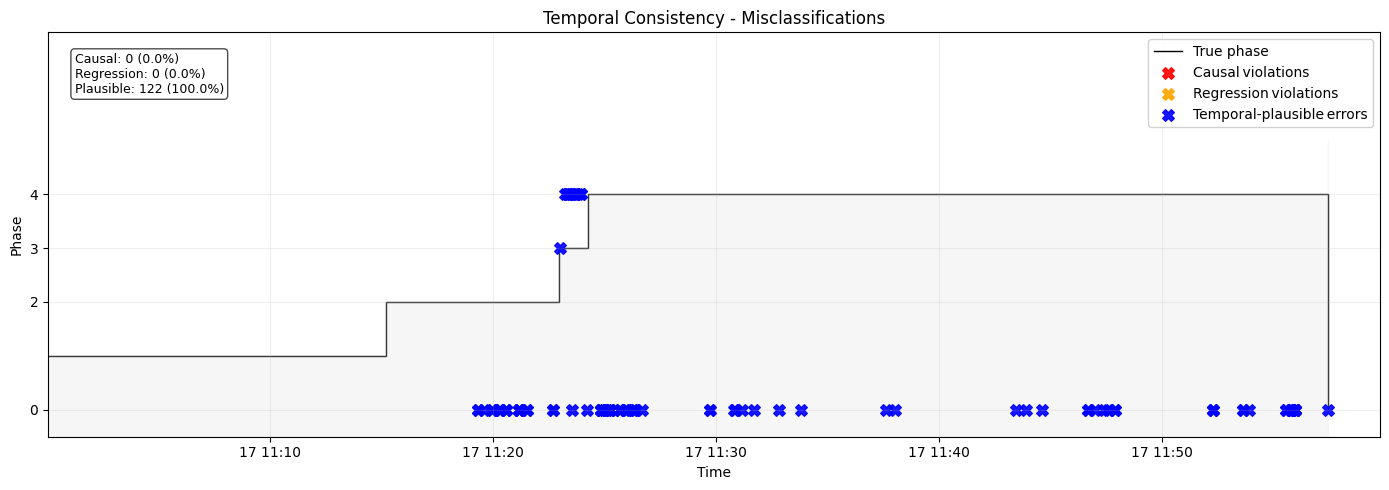

In [40]:
results = []

print(f"Processing logic file: {logic_file}")

# --- Load errors ---
err_folder = Path(f"../experiments/{dataset}/{scenario}/deepproblog/{logic_file}/errors/")
file_paths = list(err_folder.iterdir())

for file_path in file_paths:

    experiment_name_full = str(file_path.stem)
    experiment_name = experiment_name_full[:-16] # Remove "run_id"
    parts = experiment_name.split("_")
    
    cache_file_name = f"{logic_file}_{parts[-2]}_{parts[-1]}_test.pkl"

    # due to bug
    if parts[-1] != "full":
        continue
    print(f"Processing {experiment_name}")
    
    cache_df = load_dpl_dataset(logic_file, cache_file_name)

    with open(file_path, "r") as f:
        errors = json.load(f)
    
    dpl_to_orig = dict(zip(cache_df['dpl_index'], cache_df['orig_index']))

    original_indices = []
    mis_y_preds = []
    mis_y_trues = []

    for error in errors:
        dpl_index = error['index']
        original_indices.append(dpl_to_orig[dpl_index])

        y_pred = error['predicted']
        y_true = error['actual']
        mis_y_preds.append(phase_map[y_pred])
        mis_y_trues.append(phase_map[y_true])

    misclassified = df.loc[original_indices].copy()
    misclassified['y_pred'] = mis_y_preds
    misclassified['y_true'] = mis_y_trues

    print(f"Experiment: {experiment_name_full}")
    metrics = experiments[experiment_name_full]['metrics']

    f1 = metrics["macro_f1"]
    wrong, causal, regression, plausible, temp_metrics_dict = temp_metrics(misclassified, f1, phase_starts)
    
    results.append({
        "model": f"{experiment_name_full}",
        "accuracy": metrics["accuracy"],
        "precision" : metrics["macro_precision"],
        "recall" : metrics["macro_recall"], 
        "f1": metrics["macro_f1"],
        "FPR": metrics["false_alarm_rate"],
        "Detection Rate": metrics["detection_rate"],
        "total_wrong": temp_metrics_dict["total_wrong"],
        "num_causal": temp_metrics_dict["num_causal"],
        "num_regression": temp_metrics_dict["num_regression"],
        "num_plausible": temp_metrics_dict["num_plausible"],
        "causal_rate": temp_metrics_dict["causal_rate"],
        "regression_rate": temp_metrics_dict["regression_rate"],
        "plausible_rate": temp_metrics_dict["plausible_rate"],
        "temp_score": temp_metrics_dict["temp_score"]
    })

    # Create plots
    out_dir = plots_dir / logic_file / "temp_plots"
    out_dir.mkdir(parents=True, exist_ok=True)

    plot_temp_consistency(
        df, 
        phase_bounds, 
        causal,
        regression,
        plausible,
        temp_metrics_dict,
        exp_name=experiment_name_full, 
        out_dir = out_dir,
        attack_start=attack_start,
        attack_end=attack_end,
        save_plot=True,
        show_plot=False
    )


## Metrics for All Models

In [41]:
results_df = pd.DataFrame(results)
results_df

,model,accuracy,precision,recall,f1,FPR,Detection Rate,total_wrong,num_causal,num_regression,num_plausible,causal_rate,regression_rate,plausible_rate,temp_score
0,ait_logic_scratch_aug_w10_full_20260505_153536,0.999135,0.88533,0.823131,0.848015,0.000232,0.987889,122,0,0,122,0.0,0.0,1.0,0.848015


In [42]:
results_df_sorted_f1 = results_df.sort_values("f1", ascending=False)

# Save metrics to file
results_df_sorted_f1.to_csv(
    plots_dir / logic_file / "metrics.csv",
    index=False
)

In [43]:
results_df_sorted_f1.head()

,model,accuracy,precision,recall,f1,FPR,Detection Rate,total_wrong,num_causal,num_regression,num_plausible,causal_rate,regression_rate,plausible_rate,temp_score
0,ait_logic_scratch_aug_w10_full_20260505_153536,0.999135,0.88533,0.823131,0.848015,0.000232,0.987889,122,0,0,122,0.0,0.0,1.0,0.848015


In [44]:
results_df_sorted_temp = results_df.sort_values("temp_score", ascending=False)

results_df_sorted_temp.head()

,model,accuracy,precision,recall,f1,FPR,Detection Rate,total_wrong,num_causal,num_regression,num_plausible,causal_rate,regression_rate,plausible_rate,temp_score
0,ait_logic_scratch_aug_w10_full_20260505_153536,0.999135,0.88533,0.823131,0.848015,0.000232,0.987889,122,0,0,122,0.0,0.0,1.0,0.848015
